# Tutorial: Autoregressive Simulation and Dynamic Functional Connectivity

This tutorial demonstrates how to simulate autoregressive (AR) data using `frites` and estimate Dynamic Functional Connectivity (DFC).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from frites import set_mpl_style
from frites.simulations import StimSpecAR
from frites.conn import conn_dfc, define_windows

set_mpl_style()

/home/INT/brovelli.a/code/frites/frites/__init__.py:58: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 3. Auto-regressive model

We simulate a pairwise AR model where a source signal $X$ drives a target signal $Y$. The signals are designed to oscillate at 40Hz.

### 3a & 3b. Single Stimulus Simulation
We generate 100 trials with a single stimulus type.


40Hz oscillations AR model (n_times=300, n_epochs=100, n_stim=1, random_state=42)


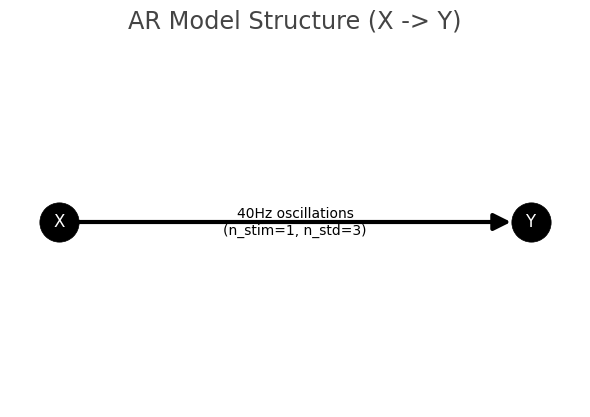

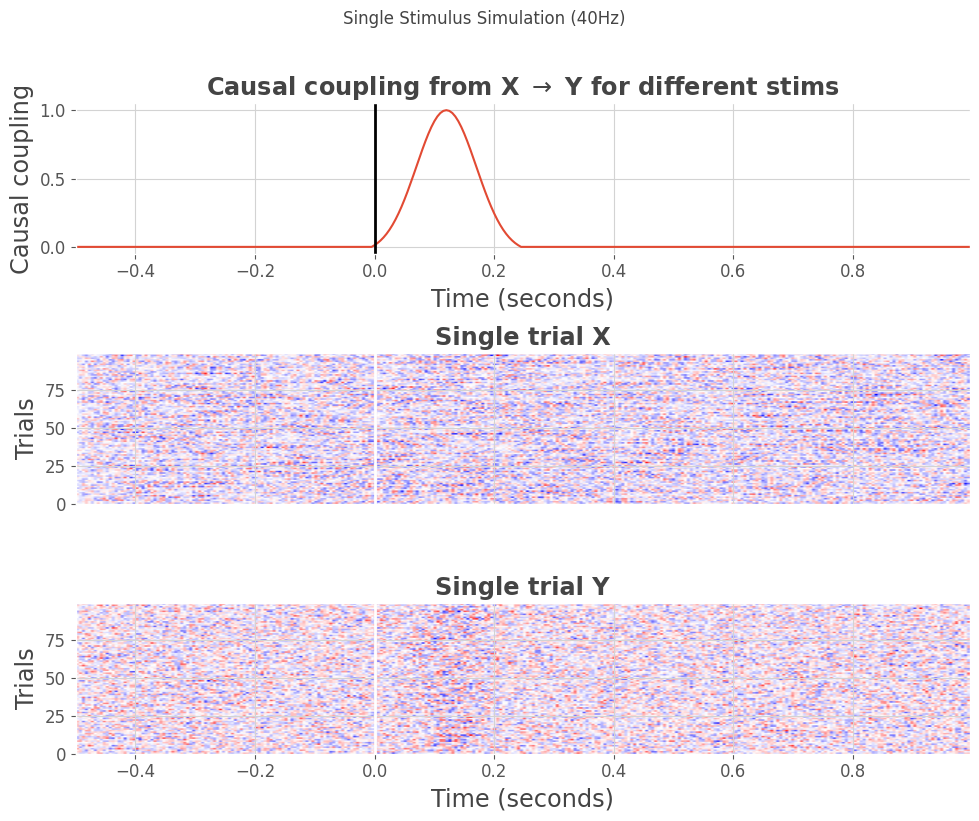

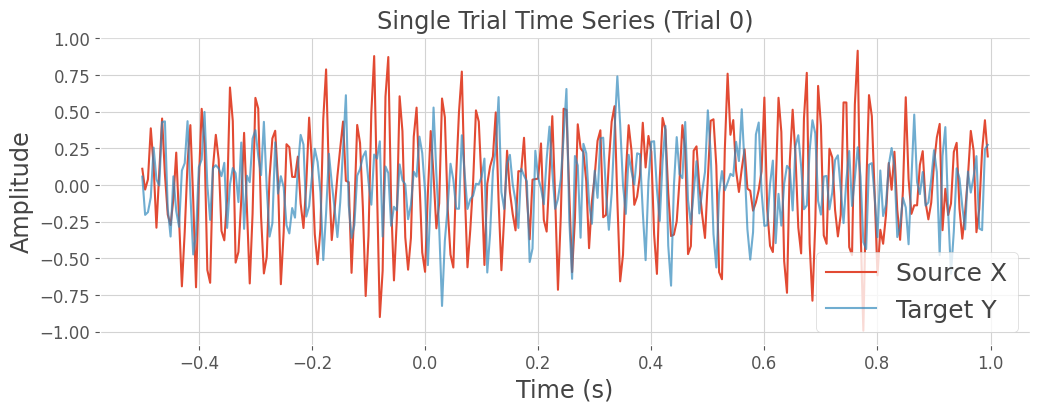

In [2]:
# Simulation parameters
ar_type = 'osc_40'
n_epochs = 100
n_stim = 1

# Initialize and fit the AR model
ss = StimSpecAR()
ar = ss.fit(ar_type=ar_type, n_epochs=n_epochs, n_stim=n_stim, random_state=42)

# Plot the model structure
plt.figure(figsize=(6, 4))
ss.plot_model()
plt.title("AR Model Structure (X -> Y)")
plt.show()

# Plot the data and causal coupling
plt.figure(figsize=(10, 8))
ss.plot(cmap='bwr')
plt.suptitle('Single Stimulus Simulation (40Hz)', y=1.02)
plt.tight_layout()
plt.show()

# Extract and plot time series for a single trial
times = ar.times.data
trial_idx = 0

plt.figure(figsize=(12, 4))
plt.plot(times, ar.isel(trials=trial_idx, roi=0), label='Source X')
plt.plot(times, ar.isel(trials=trial_idx, roi=1), label='Target Y', alpha=0.7)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Single Trial Time Series (Trial {trial_idx})')
plt.legend()
plt.show()

### 3c. Multiple Stimuli Simulation
We generate 100 trials with three different stimuli.


40Hz oscillations AR model (n_times=300, n_epochs=100, n_stim=3, random_state=42)


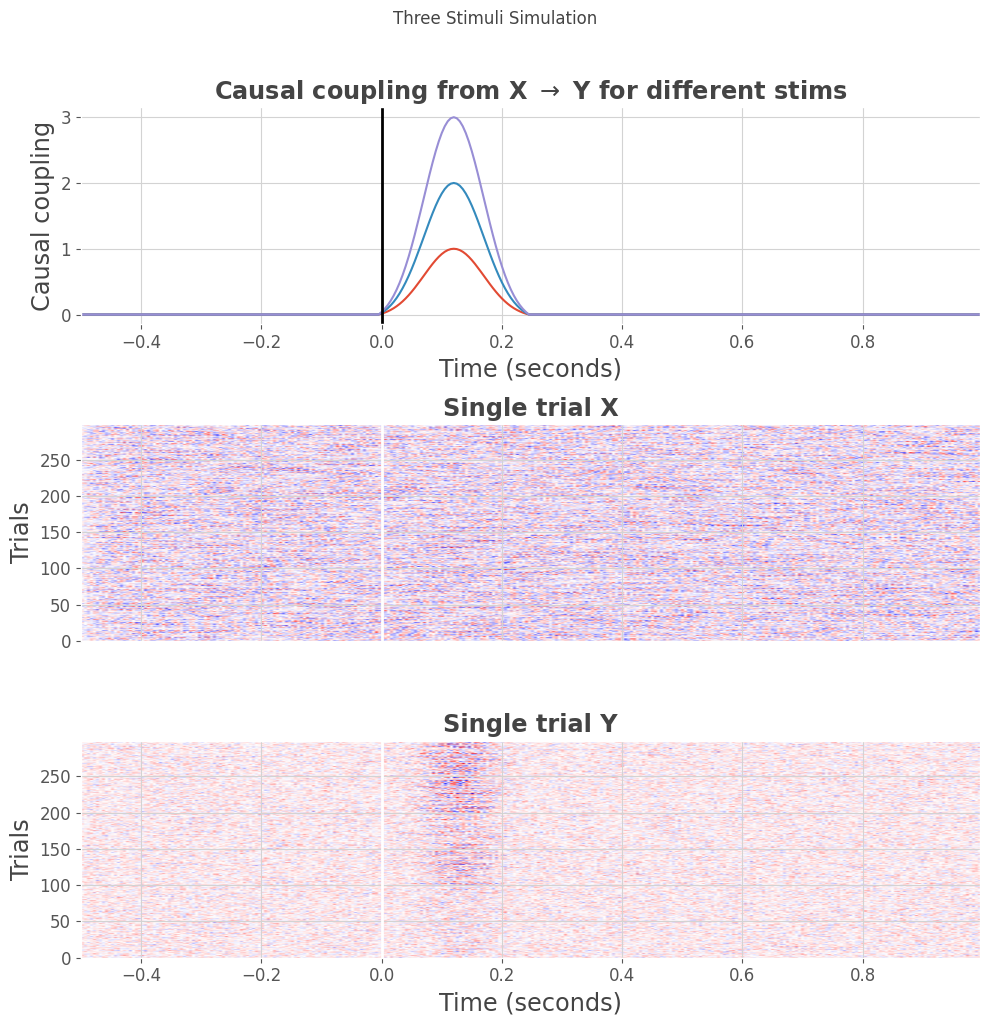

In [3]:
n_stim_3 = 3

ss_3 = StimSpecAR()
ar_3 = ss_3.fit(ar_type=ar_type, n_epochs=n_epochs, n_stim=n_stim_3, random_state=42)

plt.figure(figsize=(10, 10))
ss_3.plot(cmap='bwr')
plt.suptitle('Three Stimuli Simulation', y=1.02)
plt.tight_layout()
plt.show()

### 3d. AR Model Equation

Based on the `StimSpecAR` source code for `osc_40`, the data is generated using the following equations:

$$
X_t = \eta_{1,t} + 0.55 X_{t-1} - 0.8 X_{t-2}
$$

$$
Y_t = \eta_{2,t} + 0.35 Y_{t-1} - 0.5 Y_{t-2} + C_{2,t} (0.5 X_{t-1})
$$

Where:
*   $X_t, Y_t$ are the signal values at time $t$.
*   $\eta_{1,t}, \eta_{2,t}$ are independent Gaussian noise processes.
*   $C_{2,t}$ is the time-varying coupling strength, modulated by the stimulus (a Gaussian profile over time).


## 4. Single-trial time-resolved (dynamic) Functional Connectivity

We estimate the Dynamic Functional Connectivity (DFC) between X and Y using the data from the single-stimulus simulation (3b).

### 4a. Compute DFC
We use a sliding window approach with `window_length = 0.75s` and `win_step = 0.02s`.


Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.75, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining links (n_roi=2; directed=False; net=False, nb_min_links=None)
    Sorting roi names
Gaussian Copula Mutual Information Estimator (mi_type=cc, copnorm=False, biascorrect=False, demeaned=False)
Computing DFC between 1 pairs (gcrn=False)
/home/INT/brovelli.a/code/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| Estimating DFC : 1/1 [00:00<00:00,  210.14it/s]


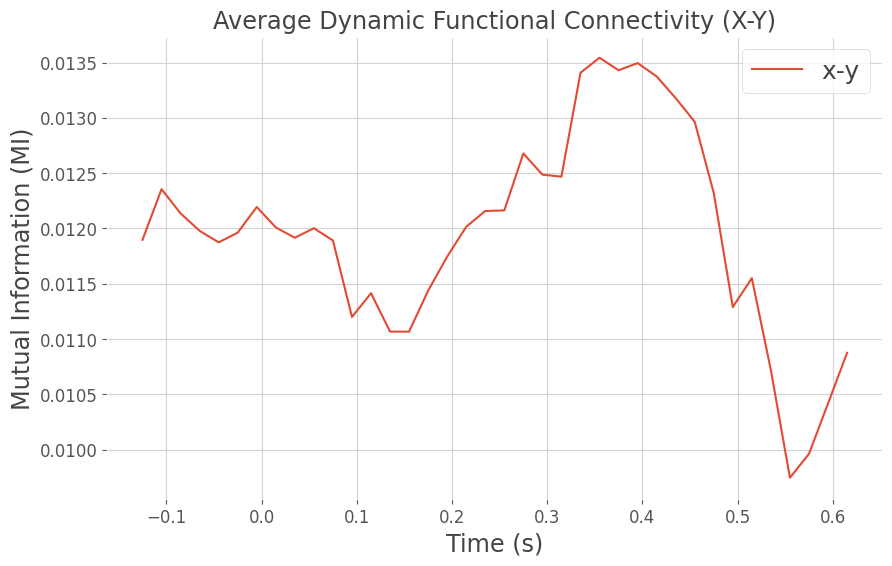

In [4]:
# Define parameters
slwin_len = 0.75    # Window length in seconds
slwin_step = 0.02   # Step size in seconds

# Define sliding windows
win_sample = define_windows(times, slwin_len=slwin_len, slwin_step=slwin_step)[0]

# Compute DFC
dfc = conn_dfc(ar, win_sample, times=times, roi=ar.roi.data, n_jobs=1)

# Plot average DFC across trials
dfc_mean = dfc.mean('trials')

plt.figure(figsize=(10, 6))
for roi_pair in dfc_mean.roi.data:
    plt.plot(dfc_mean.times, dfc_mean.sel(roi=roi_pair), label=roi_pair)

plt.title("Average Dynamic Functional Connectivity (X-Y)")
plt.xlabel("Time (s)")
plt.ylabel("Mutual Information (MI)")
plt.legend()
plt.show()

### 4b. Analyze Window Length Impact
We test different window lengths to observe the trade-off between temporal resolution and estimation stability.


Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.1, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.5, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=0.75, start=-0.5, stop=0.9950000000000001, step=0.02)
Defining temporal windows (sfreq=199.99999999999983)
    Definition of sliding windows (len=1.0, start=-0.5, stop=0.9950000000000001, step=0.02)


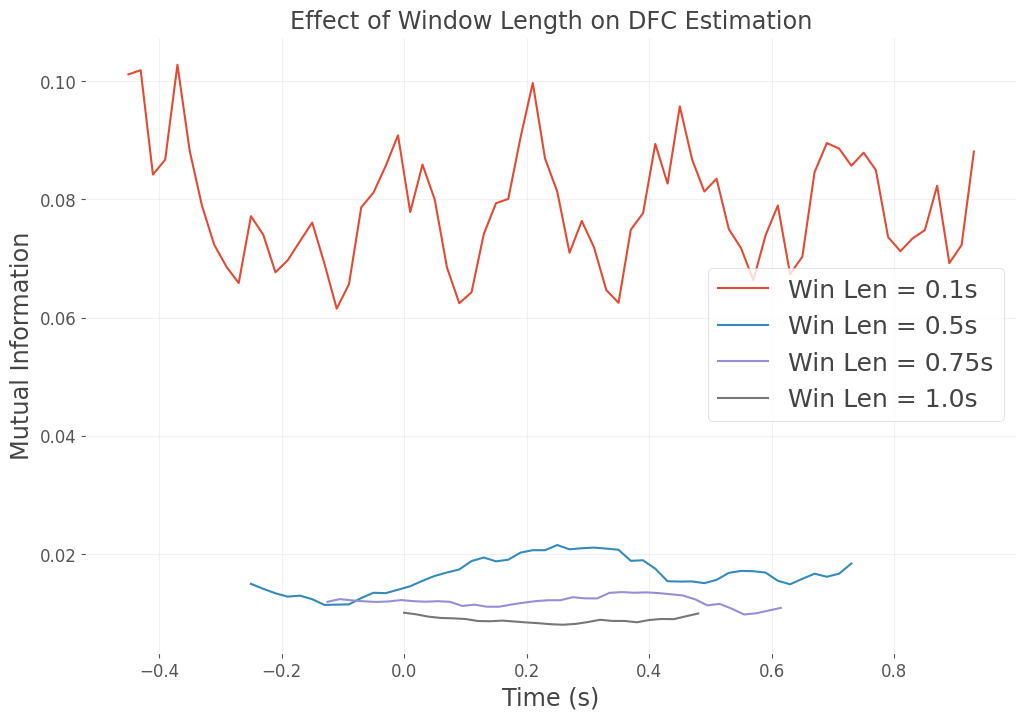

In [5]:
window_lengths = [0.1, 0.5, 0.75, 1.0]
plt.figure(figsize=(12, 8))

for wl in window_lengths:
    win_s = define_windows(times, slwin_len=wl, slwin_step=slwin_step)[0]
    
    # Compute DFC
    dfc_test = conn_dfc(ar, win_s, times=times, roi=ar.roi.data, verbose=False)
    
    # Plot average (assuming the first pair is the one of interest)
    pair_of_interest = dfc_test.roi.data[0] 
    
    plt.plot(dfc_test.mean('trials').times, 
             dfc_test.mean('trials').sel(roi=pair_of_interest), 
             label=f'Win Len = {wl}s')

plt.title("Effect of Window Length on DFC Estimation")
plt.xlabel("Time (s)")
plt.ylabel("Mutual Information")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Interpretation:
# Shorter windows (e.g., 0.1s) provide higher temporal resolution but noisier estimates.
# Longer windows (e.g., 1.0s) provide smoother estimates but smooth out temporal dynamics (smearing).
